In [3]:
import pandas as pd

In [4]:
url = "https://docs.google.com/spreadsheets/d/1AjcqmM5kkCniTcL2gINvpiub-vefKA0nZR2Ln3eUFL8/export?format=csv"

df = pd.read_csv(url)

In [5]:
df.head()

,Review Id,Review,Ratings,Review Date
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,2024-08-23 19:20:39


In [6]:
#Information required before starting the analysis
print("Info about the dataset:")
df.info()

Info about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196727 entries, 0 to 196726
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Review Id    196727 non-null  object
 1   Review       196721 non-null  object
 2   Ratings      196727 non-null  int64 
 3   Review Date  196727 non-null  object
dtypes: int64(1), object(3)
memory usage: 6.0+ MB


In [7]:
df['Review Date'] = pd.to_datetime(df['Review Date'])

df.dtypes

Review Id              object
Review                 object
Ratings                 int64
Review Date    datetime64[ns]
dtype: object

In [8]:
print("\nInfo about the data itself:")
df.describe()


Info about the data itself:


,Ratings,Review Date
count,196727.000000,196727
mean,4.503535,2024-03-25 22:03:05.784020736
min,1.000000,2023-07-25 15:01:35
25%,5.000000,2024-01-06 09:47:07
50%,5.000000,2024-04-22 20:53:30
75%,5.000000,2024-06-24 16:43:04.500000
max,5.000000,2024-08-23 19:30:05
std,1.083004,NaN


In [9]:
print("\nNo. of duplicate rows in the dataset")
df.duplicated().sum()


No. of duplicate rows in the dataset


np.int64(2511)

In [10]:
print("\nNo. of null values in the dataset")
df.isnull().sum()


No. of null values in the dataset


Review Id      0
Review         6
Ratings        0
Review Date    0
dtype: int64

In [11]:
df[df['Review'].isnull()]

,Review Id,Review,Ratings,Review Date
35896,6d2f3aaa-babf-4105-9743-fa31462a526d,NaN,1,2024-07-11 18:15:05
49374,a6fc983e-8729-4d78-8cdf-25a47194932d,NaN,1,2024-06-24 06:20:22
155476,ffc32dd8-45b3-44a0-b8cf-8bd83ec5a621,NaN,1,2024-04-25 06:07:13
162561,527e0514-b444-4c59-b0a9-7f7774335ece,NaN,5,2024-04-04 18:56:52
169011,a16c4191-19e8-4cc2-b072-0118fae7b5f4,NaN,5,2024-03-23 23:03:54
169192,4c07a17f-5c2a-489b-8136-49fae85a6cfa,NaN,5,2024-03-29 13:52:29


In [12]:
df['Ratings'].value_counts().sort_index()

Ratings
1     12083
2      3375
3      8157
4     22897
5    150215
Name: count, dtype: int64

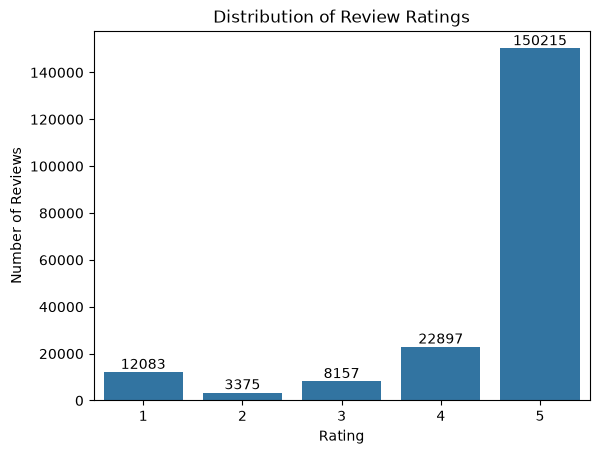

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

ax=sns.countplot(x='Ratings', data=df)

plt.title('Distribution of Review Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')

ax.bar_label(ax.containers[0], fmt='%d')

plt.show()

In [14]:
print("Earliest review:", df['Review Date'].min())
print("Latest review:", df['Review Date'].max())

Earliest review: 2023-07-25 15:01:35
Latest review: 2024-08-23 19:30:05


In [15]:
monthly_reviews = df['Review Date'].dt.to_period('M').value_counts().sort_index()

monthly_reviews = monthly_reviews.reset_index()

monthly_reviews

,Review Date,count
0,2023-07,8283
1,2023-08,6801
2,2023-09,7593
3,2023-10,5824
4,2023-11,8719
5,2023-12,10375
6,2024-01,9313
7,2024-02,8748
8,2024-03,15175
9,2024-04,23739


In [16]:
monthly_reviews = monthly_reviews.rename(columns={'count': 'Review Count'})

monthly_reviews['Review Date'] = monthly_reviews['Review Date'].dt.to_timestamp()

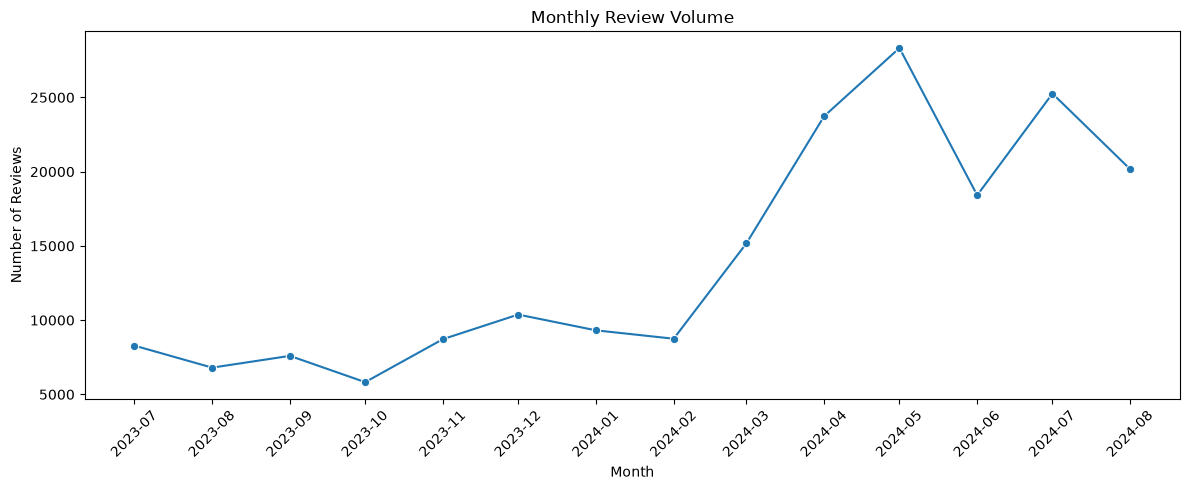

In [17]:
import matplotlib.dates as mdates
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_reviews,
    x='Review Date',
    y='Review Count',
    marker='o'
)

plt.title('Monthly Review Volume')
plt.xlabel('Month')
plt.ylabel('Number of Reviews')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(monthly_reviews['Review Date'], rotation=45)
plt.tight_layout()

plt.show()

In [18]:
df = df.drop_duplicates()

#percentage of each rating
df['Ratings'].value_counts(normalize=True).sort_index() * 100

Ratings
1     6.161181
2     1.722824
3     4.142810
4    11.638073
5    76.335111
Name: proportion, dtype: float64

In [19]:
df['Review Month'] = df['Review Date'].dt.to_period('M')

monthly_rating = df.groupby('Review Month')['Ratings'].mean()

monthly_rating = monthly_rating.reset_index()

monthly_rating

,Review Month,Ratings
0,2023-07,4.439454
1,2023-08,4.327746
2,2023-09,4.494534
3,2023-10,4.525755
4,2023-11,4.523913
5,2023-12,4.514217
6,2024-01,4.470955
7,2024-02,4.487997
8,2024-03,4.491598
9,2024-04,4.533805


In [20]:
monthly_rating['Review Month'] = monthly_rating['Review Month'].dt.to_timestamp()

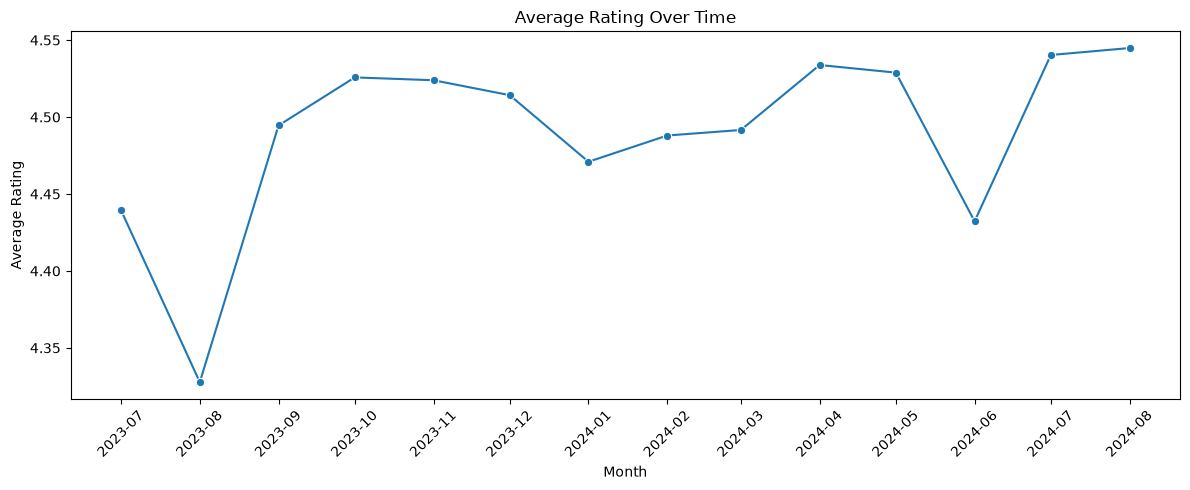

In [21]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_rating,
    x='Review Month',
    y='Ratings',
    marker='o'
)

plt.title('Average Rating Over Time')
plt.xlabel('Month')
plt.ylabel('Average Rating')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(monthly_rating['Review Month'], rotation=45)

plt.tight_layout()
plt.show()

In [22]:
print(df['Review'].head())

df['Review'].str.len().describe()

0                                                 good
1                                                 good
2                                             nice app
3                                             nice, ig
4    this is a great app, the bot is so accurate to...
Name: Review, dtype: object


count    194210.000000
mean         46.777560
std          75.247322
min           1.000000
25%           9.000000
50%          18.000000
75%          50.000000
max         500.000000
Name: Review, dtype: float64

In [23]:
df['Review'].str.len().value_counts().sort_index().head(20)

Review
1.0      1436
2.0      1643
3.0      1851
4.0     17402
5.0      4495
6.0      3806
7.0      7528
8.0      7302
9.0     12332
10.0     4142
11.0     6014
12.0     5525
13.0     5366
14.0     4122
15.0     3964
16.0     3932
17.0     3359
18.0     3054
19.0     2804
20.0     2671
Name: count, dtype: int64

In [24]:
print("Reviews with 10 or fewer characters:",
      (df['Review'].str.len() <= 10).sum())

print("Reviews with 20 or fewer characters:",
      (df['Review'].str.len() <= 20).sum())

Reviews with 10 or fewer characters: 61937
Reviews with 20 or fewer characters: 102748


In [25]:
df['Review Length'] = df['Review'].str.len()
df['Review Length'].head()
df['Review Length'].dtype

dtype('float64')

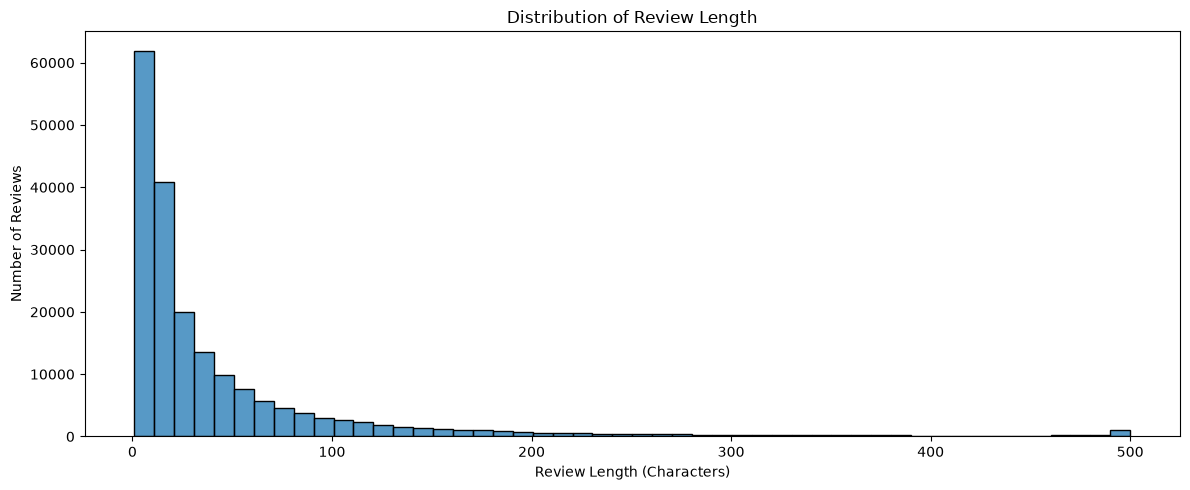

In [26]:
plt.close('all')

plt.figure(figsize=(12, 5))

sns.histplot(
    data=df,
    x='Review Length',
    bins=50
)

plt.title('Distribution of Review Length')
plt.xlabel('Review Length (Characters)')
plt.ylabel('Number of Reviews')

plt.tight_layout()
plt.show()

In [27]:
df['Length Category'] = pd.cut(
    df['Review Length'],
    bins=[0, 10, 20, 50, 100, 200, 500],
    labels=['1-10', '11-20', '21-50', '51-100', '101-200', '201-500']
)

df['Length Category'].value_counts().sort_index()

Length Category
1-10       61937
11-20      40811
21-50      43447
51-100     24617
101-200    14622
201-500     8776
Name: count, dtype: int64

In [28]:
length_rating = df.groupby(
    'Length Category',
    observed=True
)['Ratings'].mean().reset_index()

df.groupby('Length Category')['Ratings'].mean()


C:\Users\saika\AppData\Local\Temp\ipykernel_23124\2289904067.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Length Category')['Ratings'].mean()


Length Category
1-10       4.663658
11-20      4.673078
21-50      4.507975
51-100     4.304871
101-200    4.045343
201-500    3.864745
Name: Ratings, dtype: float64

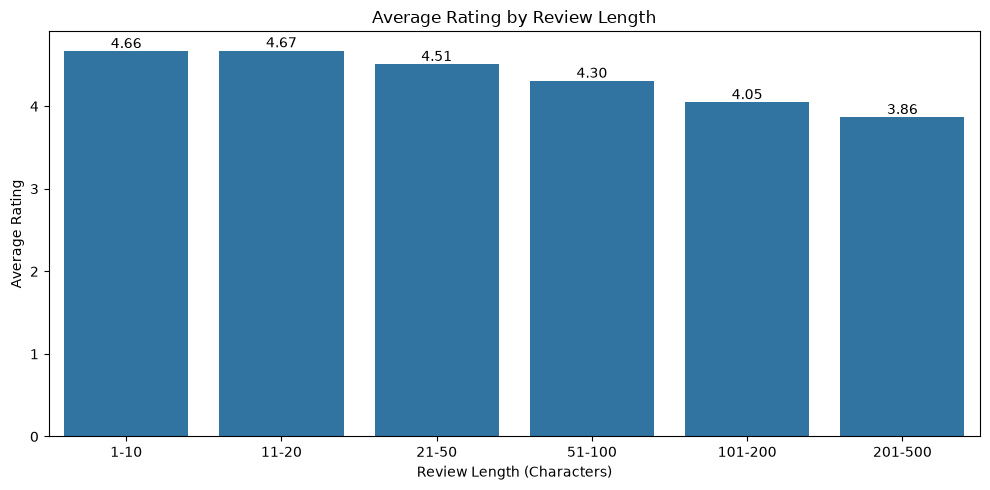

In [29]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=length_rating,
    x='Length Category',
    y='Ratings'
)

plt.title('Average Rating by Review Length')
plt.xlabel('Review Length (Characters)')
plt.ylabel('Average Rating')

ax.bar_label(ax.containers[0], fmt='%.2f')

plt.tight_layout()
plt.show()

In [30]:
df = df.dropna(subset=['Review'])

In [31]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\saika\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [32]:
sia = SentimentIntensityAnalyzer()

In [33]:
test_review = df['Review'].iloc[0]

print(test_review)
print(sia.polarity_scores(test_review))

good
{'neg': 0.0, 'neu': 0.0, 'pos': 1.0, 'compound': 0.4404}


In [34]:
df['Sentiment Score'] = df['Review'].apply(
    lambda x: sia.polarity_scores(x)['compound']
)

In [35]:
df[['Review', 'Sentiment Score']].head(10)

,Review,Sentiment Score
0,good,0.4404
1,good,0.4404
2,nice app,0.4215
3,"nice, ig",0.4215
4,"this is a great app, the bot is so accurate to...",0.9427
5,so nice app,0.4754
6,"just love this app, or guy",0.6369
7,great app,0.6249
8,Very impressive,0.5563
9,helps with coding a lot this ai is great for e...,0.7717


In [36]:
df['Sentiment'] = df['Sentiment Score'].apply(
    lambda x: 'Positive' if x >= 0.05
    else 'Negative' if x <= -0.05
    else 'Neutral'
)

df['Sentiment'].value_counts()

Sentiment
Positive    148610
Neutral      34905
Negative     10695
Name: count, dtype: int64

In [37]:
df['Sentiment'].value_counts(normalize=True) * 100

Sentiment
Positive    76.520262
Neutral     17.972813
Negative     5.506925
Name: proportion, dtype: float64

In [38]:
pd.crosstab(df['Ratings'], df['Sentiment'])

Sentiment,Negative,Neutral,Positive
Ratings,,,
1,4668,3832,3463
2,1011,855,1480
3,1225,1744,5077
4,1373,3477,17753
5,2418,24997,120837


In [39]:
rating_sentiment_pct = pd.crosstab(
    df['Ratings'],
    df['Sentiment'],
    normalize='index'
) * 100

rating_sentiment_pct

Sentiment,Negative,Neutral,Positive
Ratings,,,
1,39.020313,32.032099,28.947588
2,30.215182,25.552899,44.231919
3,15.224957,21.675367,63.099677
4,6.074415,15.382914,78.542671
5,1.631007,16.861155,81.507838


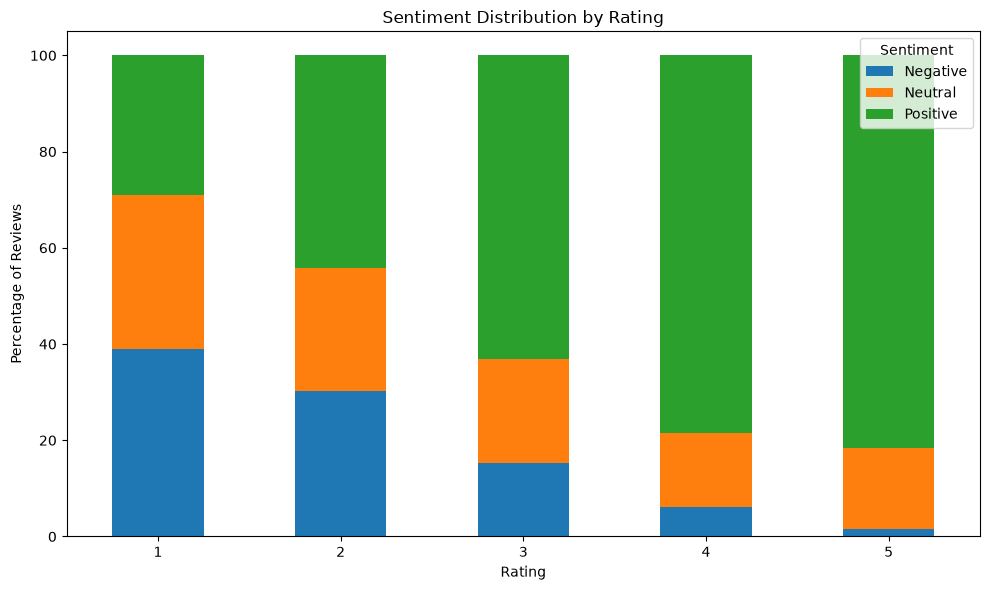

In [40]:
rating_sentiment_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title('Sentiment Distribution by Rating')
plt.xlabel('Rating')
plt.ylabel('Percentage of Reviews')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')

plt.tight_layout()
plt.show()

In [41]:
one_star_positive = df[
    (df['Ratings'] == 1) &
    (df['Sentiment'] == 'Positive')
]

one_star_positive[['Review', 'Sentiment Score']].head(20)

,Review,Sentiment Score
7,great app,0.6249
115,Why does this app keep telling me an error has...,0.1779
217,we should need chat gpt plus for free.,0.5106
274,good,0.4404
299,good,0.4404
303,This is not nice app I hate it 😡,0.1695
356,When I was exam class 10 I achieve marks 500/4...,0.6369
375,This app doesn't have unlimited pic this app s...,0.4261
423,Log in to save chats. Except the one you've be...,0.4939
441,it's very good app I really really appreciate ...,0.7554


In [42]:
five_star_negative = df[
    (df['Ratings'] == 5) &
    (df['Sentiment'] == 'Negative')
]

five_star_negative[['Review', 'Sentiment Score']].head(20)

,Review,Sentiment Score
97,nothing can be better than this in the new gen...,-0.3412
184,"recently I've been having an issue , that when...",-0.2755
189,good for cheating in school,-0.1779
430,This is one of the more dependable AI's out th...,-0.2144
676,Very Recommendable for students who are stress...,-0.4559
832,Beacause this apo can solve your problem!!,-0.3578
885,Most reliable and versatile AI at the moment. ...,-0.6597
963,Great 👍👍 ChatGPT I have never see such a beaut...,-0.0575
1023,Awful. I don't know how they managed to make G...,-0.9535
1196,anything any problem solison in chat gpt,-0.4019


In [48]:
negative_reviews = df.loc[df['Sentiment'] == 'Negative', 'Review']

negative_text = ' '.join(negative_reviews)

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\saika\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [50]:
import re
from collections import Counter
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

words = re.findall(r"\b[a-zA-Z']+\b", negative_text.lower())

filtered_words = [
    word for word in words
    if word not in stop_words and len(word) > 2
]

word_counts = Counter(filtered_words)

word_counts.most_common(20)


[('app', 3347),
 ('good', 1164),
 ('wrong', 1027),
 ('chatgpt', 927),
 ('error', 920),
 ("can't", 877),
 ('bad', 870),
 ('problem', 867),
 ('use', 825),
 ('time', 807),
 ('even', 733),
 ('chat', 712),
 ('answer', 711),
 ('like', 645),
 ('information', 605),
 ('answers', 542),
 ('give', 534),
 ('please', 529),
 ('gpt', 518),
 ('sometimes', 514)]

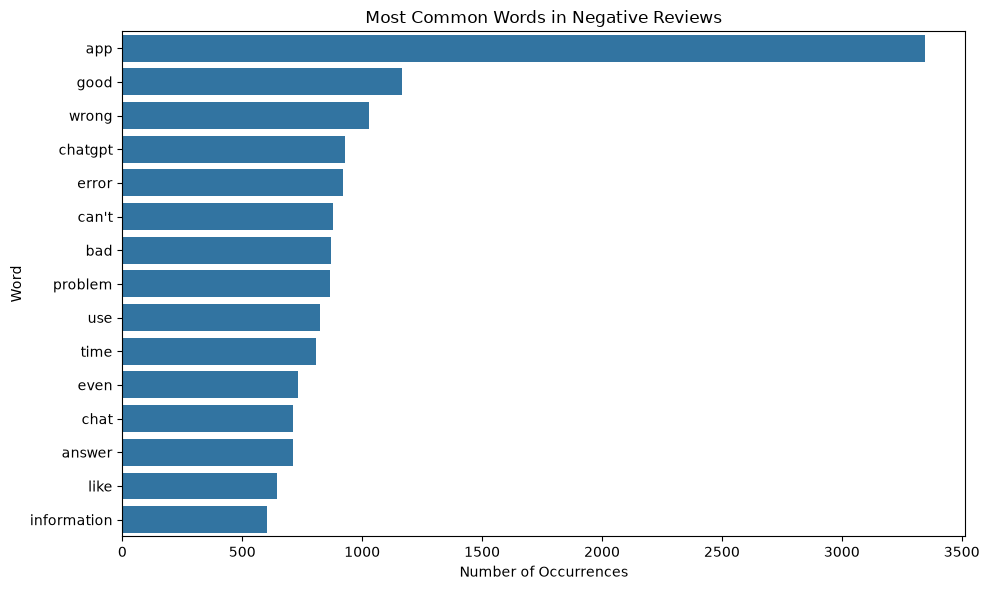

In [51]:
top_words = pd.DataFrame(
    word_counts.most_common(15),
    columns=['Word', 'Count']
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_words,
    x='Count',
    y='Word'
)

plt.title('Most Common Words in Negative Reviews')
plt.xlabel('Number of Occurrences')
plt.ylabel('Word')

plt.tight_layout()
plt.show()